In [1]:
!pip install networkx matplotlib

Optimal Routing Path: Server_A -> Router_1 -> Router_2 -> Target_DB
Total Network Latency: 7ms
Network map saved as 'shortest_path_routing_test.png'


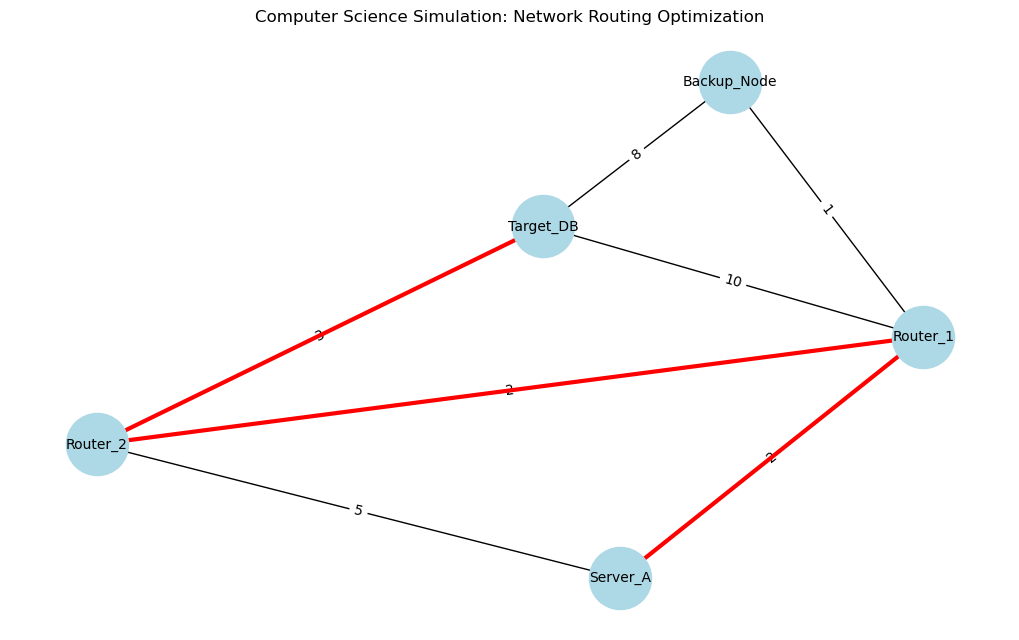

In [1]:
import networkx as nx
import matplotlib.pyplot as plt

# 1. Create a "Network" of computers
G = nx.Graph()

# Add nodes and "weights" (latency in milliseconds)
connections = [
    ('Server_A', 'Router_1', 2),
    ('Server_A', 'Router_2', 5),
    ('Router_1', 'Router_2', 2),
    ('Router_1', 'Target_DB', 10),
    ('Router_2', 'Target_DB', 3),
    ('Router_1', 'Backup_Node', 1),
    ('Backup_Node', 'Target_DB', 8)
]

G.add_weighted_edges_from(connections)

# 2. Simulate Dijkstra's Algorithm
start_node = 'Server_A'
end_node = 'Target_DB'
path = nx.dijkstra_path(G, start_node, end_node)
path_length = nx.dijkstra_path_length(G, start_node, end_node)

print(f"Optimal Routing Path: {' -> '.join(path)}")
print(f"Total Network Latency: {path_length}ms")

# 3. Visualization
pos = nx.spring_layout(G)  # Positioning nodes
plt.figure(figsize=(10, 6))

# Draw all nodes and edges
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=2000, font_size=10)
labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)

# Highlight the calculated path in red
path_edges = list(zip(path, path[1:]))
nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color='red', width=3)

plt.title(f"Computer Science Simulation: Network Routing Optimization")
plt.savefig('shortest_path_routing_test.png')
print("Network map saved as 'shortest_path_routing_test.png'")